# Imports

In [10]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional

from interval_timeline import CallGraph
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt

# Preamble

### Trace Constants
Define some constants for the traces to load

In [11]:
# Glob everything from `./scorep-traces/frontierXXXXX-rochpl-*`
ROCHPL_TRACES = [
    f"./scorep-traces/{d}/traces.otf2"
	for d in os.listdir("./scorep-traces")
	if re.match(r"frontier\d+-rochpl-.*", d)
]

ROCHPL_MXP_TRACES = [
    f"./scorep-traces/{d}/traces.otf2"
	for d in os.listdir("./scorep-traces")
	if re.match(r"frontier\d+-rochplmxp-.*", d)
]

HPG_TRACES = [
    f"./scorep-traces/{d}/traces.otf2"
	for d in os.listdir("./scorep-traces")
	if re.match(r"frontier\d+-xhpgmp---runtype=standalone_ref", d)
]

HPG_MXP_TRACES = [
    f"./scorep-traces/{d}/traces.otf2"
	for d in os.listdir("./scorep-traces")
	if re.match(r"frontier\d+-xhpgmp---runtype=standalone_mxp", d)
]

print("ROCHPL_TRACES:", ROCHPL_TRACES)
print("ROCHPL_MXP_TRACES:", ROCHPL_MXP_TRACES)
print("HPG_TRACES:", HPG_TRACES)
print("HPG_MXP_TRACES:", HPG_MXP_TRACES)


    

ROCHPL_TRACES: ['./scorep-traces/frontier00137-rochpl--P_1_-Q_8_-N_180224/traces.otf2', './scorep-traces/frontier02329-rochpl--P_1_-Q_8_-N_180224/traces.otf2', './scorep-traces/frontier00133-rochpl--P_1_-Q_8_-N_180224/traces.otf2']
ROCHPL_MXP_TRACES: ['./scorep-traces/frontier00137-rochplmxp--P_1_-Q_8_-N_180224/traces.otf2', './scorep-traces/frontier00133-rochplmxp--P_1_-Q_8_-N_180224/traces.otf2']
HPG_TRACES: ['./scorep-traces/frontier00133-xhpgmp---runtype=standalone_ref/traces.otf2', './scorep-traces/frontier00137-xhpgmp---runtype=standalone_ref/traces.otf2']
HPG_MXP_TRACES: ['./scorep-traces/frontier00143-xhpgmp---runtype=standalone_mxp/traces.otf2', './scorep-traces/frontier00146-xhpgmp---runtype=standalone_mxp/traces.otf2', './scorep-traces/frontier00133-xhpgmp---runtype=standalone_mxp/traces.otf2', './scorep-traces/frontier00137-xhpgmp---runtype=standalone_mxp/traces.otf2']


### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [12]:
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
]

def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
    """Convert a CallGraph to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
        intervals = call_graph.get_intervals_between(float('-inf'), float('inf'))
        
        for interval in intervals:
            start = interval.start
            end = interval.end or float('inf')
            duration = end - start
            name = interval.name if interval.name else "Unknown"
            depth = interval.depth if interval.depth else 0

            f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name:
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    return pd.read_csv(file)


### Remove Conflicting CSVs
Remove any existing CSVs that might conflict with new ones to be generated.

In [13]:
# Remove all the old CSV files
for file in os.listdir('.'):
    if file.endswith('.csv'):
        os.remove(file)

### Setup for Loading Traces
Convert an OTF2 to a CSV dataset to be loaded into a dataframe

In [14]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str], cray_time_offset=0.0):
    call_graphs = {}
    metrics = {}

    start_time = None
    timer_resolution = None

    seen: Dict[str, set[str]] = {}

    def timestamp_to_seconds(timestamp):
        """Convert a timestamp in nanoseconds to seconds."""
        if timestamp is None or start_time is None or timer_resolution is None:
            return 0.0
        return (timestamp - start_time) / timer_resolution

    with otf2.reader.open(trace) as reader:
        defs = reader.definitions
        timer_resolution = reader.timer_resolution
        print(f"Timer resolution: {timer_resolution} ticks per second ({timer_resolution / 1e9} per nanosecond)")
        print(f"Number of metric members: {len(defs.metric_members)}")
        print(f'Definitions: {defs}')
        count = 0
        for location, event in reader.events:
            count += 1
            # thread = (location.name, location.group.name)
            group = location.group.name
            if location.group.creating_location_group is not None:
                group = location.group.creating_location_group.name
            thread = location.name
            
            if group not in seen:
                seen[group] = set()
            if thread not in seen[group]:
                seen[group].add(thread)
                print(f"New thread: {thread} in group {group}")
            if group not in call_graphs:
                call_graphs[group] = {thread: CallGraph()}
            if thread not in call_graphs[group]:
                call_graphs[group][thread] = CallGraph()
            if group not in metrics:
                metrics[group] = {metric: [] for metric in METRICS_TO_TRACK}
            
            if isinstance(event, otf2.events.ProgramBegin):
                start_time = event.time
                continue
            elif isinstance(event, otf2.events.ProgramEnd):
                end_time = event.time
                continue
            
            current_time = timestamp_to_seconds(event.time)
            
            if isinstance(event, otf2.events.Metric):
                metric_name = event.member.name
                if group not in metrics:
                    continue
                if metric_name not in metrics[group]:
                    continue
                if 'cray' in metric_name and cray_time_offset != 0.0:
                    current_time -= cray_time_offset  # Adjust for craypm metrics, as they are reported with a delay
                
                if len(metrics[group][metric_name]) == 0 or metrics[group][metric_name][-1][1] != event.value:
                    # If the metrics has no initial value, append the current one
                    # If the metric has changed, append the current one
                    metrics[group][metric_name].append((current_time, event.value))
                
            if group not in processes_to_track:
                continue
            
            if isinstance(event, otf2.events.Enter):
                call_graphs[group][thread].enter(current_time, name=event.region.name)
            elif isinstance(event, otf2.events.Leave):
                try:
                    call_graphs[group][thread].leave(current_time)
                except Exception as e:
                    print(f"Error leaving call graph for {group} {thread}: {e}")
                    continue
        print(f"Processed {count} events.")
        
    for group, threads in call_graphs.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        for thread, call_graph in threads.items():
            filename = f"{group}_{thread.replace(' ', '_')}_callgraph.csv"
            print(f'Writing to file: {filename}')
            callgraph_to_csv(call_graph, group, thread, filename)

    for group, thread_metrics in metrics.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        filename = f"{group}_metrics.csv"
        print(f'Writing to file: {filename}')
        metrics_to_csv(group, thread_metrics, filename)
    
# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))


### Math Helpers

Helpers for linearly interpolating values and computing numerical integrals + derivatives

In [15]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # Apply a savgol filter to smooth the data
    # y = scipy.signal.savgol_filter(y, window_length=11, polyorder=2, mode='nearest')
    # Apply a median filter to smooth the data
    # y = scipy.signal.medfilt(y, kernel_size=11)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F
        
def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [16]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    # Asume que viene “bien formado”: cada fila es una invocación con Depth que respeta el anidamiento.
    # Si no está ordenado por Start Time, ordénalo una vez.
    df = df.sort_values(by='Start Time')

    # Filtrado opcional por duración, replica tu lógica si quieres:
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    
    # Vectoriza cálculo de métricas por fila (Δ = f(end) - f(start))
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)            # ideal: f soporta arrays
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            # Fallback si f no vectoriza
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    # Construcción del DAG con una pila indexada por profundidad
    # Mantenemos las referencias a los últimos nodos por cada Depth.
    # Cuando Depth sube, el nuevo nodo se anexa como hijo del nodo en Depth-1.
    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    # Usamos itertuples para bajo overhead
    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

        # Si retrocede la profundidad en la siguiente fila, iremos sobreescribiendo last_at_depth
        # No hace falta “cerrar” nada aún; calculamos 'time' más adelante en una segunda pasada.

    # Segunda pasada postorden para calcular 'time' = 'time (inc)' - suma hijos.
    # Podemos hacerlo con una DFS iterativa.
    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [17]:
class Rank:
	def __init__(self, node: str, name: str, call_graph_df: pd.DataFrame):
		self.node = node
		self.name = name
		self.call_graph = call_graph_df
		assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph_df.columns.tolist()}"
		
	def get_all_code_regions(self) -> List[str]:
		return self.call_graph['Name'].unique().tolist()

	def compute_attribution(
		self,
		metrics_accumulated: Dict[str, callable],
		duration_threshold: float = 0.001,
		weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
		df = self.call_graph
		df = df[df['Duration'] >= duration_threshold]
		pref3 = df['Name'].str[:3].str.lower()
		df = df[~pref3.isin(['hip', 'mpi'])]

		if df.empty:
			return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

		starts = df['Start Time'].to_numpy()
		ends   = df['End Time'].to_numpy()
		names  = df['Name'].to_numpy()

		cols = {}
		for metric, f in metrics_accumulated.items():
			try:
				deltas = f(ends) - f(starts)
				deltas = np.asarray(deltas, dtype=float)
				deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
			except Exception:
				deltas = np.fromiter(
					(unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
					dtype=float, count=len(starts)
				)

			# Apply weights if present for this metric (1.0 if not provided)
			if weights_by_metric and metric in weights_by_metric:
				w = np.asarray(weights_by_metric[metric], dtype=float)
				if w.shape[0] == deltas.shape[0]:
					deltas = deltas * w
				elif w.size == 1:
					deltas = deltas * float(w)
				else:
					# Safe fallback if the length does not match for some reason
					deltas = deltas * 1.0

			cols[metric] = deltas

		out = pd.DataFrame(cols)
		out['Code Region'] = names
		# Aggregate by region
		out = out.groupby('Code Region', as_index=False).sum()
		return out

	def refresh(self):
		return Rank(self.node, self.name, self.call_graph)

	def __str__(self):
		return f"Rank({self.name})"

class Node:
	def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
		self.name = name
		self.ranks = ranks
		self.metrics = metrics_df
		assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

	def refresh(self):
		return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

	def get_metric_names(self) -> List[str]:
		return self.metrics['Metric Name'].unique().tolist()
	
	def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
		return self.metrics[self.metrics['Metric Name'] == metric_name]

	def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
		df = rank.call_graph
		df = df[df['Duration'] >= duration_threshold]
		pref3 = df['Name'].str[:3].str.lower()
		return df[~pref3.isin(['hip', 'mpi'])]

	def _compute_sharing_weights_for_rank(
		self,
		rank: Rank,
		ranks_to_metrics: Dict[str, List[str]],
		metrics_accumulated: Dict[str, callable],
		duration_threshold: float = 0.001,
	) -> Dict[str, np.ndarray]:
		"""
		For each metric assigned to 'rank', return a weight vector (length = #events after filtering)
		that splits energy evenly among ranks using the same metric, ONLY when there is
		temporal overlap of events.
		"""
		weights_by_metric: Dict[str, np.ndarray] = {}
		df_r = self._filtered_callgraph(rank, duration_threshold)
		starts_r = df_r['Start Time'].to_numpy()
		ends_r   = df_r['End Time'].to_numpy()

		# If there are no events, nothing to weight
		if starts_r.size == 0:
			for m in ranks_to_metrics.get(rank.name, []):
				weights_by_metric[m] = np.zeros(0, dtype=float)
			return weights_by_metric

		# For each metric of the rank
		for metric in ranks_to_metrics.get(rank.name, []):
			# Ranks that share this metric on this node
			ranks_same_metric = [
				r for r in self.ranks
				if metric in ranks_to_metrics.get(r.name, [])
			]

			# Collect intervals filtered for all those ranks
			breaks = set()
			intervals_per_rank: Dict[str, List[Tuple[float, float]]] = {}
			for r in ranks_same_metric:
				df = self._filtered_callgraph(r, duration_threshold)
				s = df['Start Time'].to_numpy()
				e = df['End Time'].to_numpy()
				# Store intervals and breakpoints
				ivals = []
				for a, b in zip(s, e):
					if b > a:
						ivals.append((a, b))
						breaks.add(a); breaks.add(b)
				intervals_per_rank[r.name] = ivals

			if not breaks:
				# No shared events; full weight to the current rank
				weights_by_metric[metric] = np.ones_like(starts_r, dtype=float)
				continue

			# Sort change points and create sub-intervals
			brk = np.array(sorted(breaks), dtype=float)
			# Avoid degenerate
			brk = brk[np.isfinite(brk)]
			brk = brk[np.concatenate(([True], np.diff(brk) > 0))]

			if brk.size < 2:
				weights_by_metric[metric] = np.ones_like(starts_r, dtype=float)
				continue

			# k[i] = number of active ranks in [brk[i], brk[i+1])
			k = np.zeros(brk.size - 1, dtype=int)
			for rname, ivals in intervals_per_rank.items():
				if not ivals:
					continue
				# Mark activity per sub-interval when there is overlap
				for idx in range(brk.size - 1):
					a, b = brk[idx], brk[idx+1]
					# Does any interval of this rank overlap [a,b)?
					# (start < b) and (end > a)
					active = any((s < b) and (e > a) for s, e in ivals)
					if active:
						k[idx] += 1

			# Prepare weights for each event of the target rank
			w = np.zeros_like(starts_r, dtype=float)
			for j, (s_ev, e_ev) in enumerate(zip(starts_r, ends_r)):
				if not np.isfinite(s_ev) or not np.isfinite(e_ev) or e_ev <= s_ev:
					w[j] = 0.0
					continue

				# Integrate (1/k) over the overlap of the event with the sub-intervals
				# and normalize by the event duration (time-average)
				num = 0.0
				denom = e_ev - s_ev
				# Find indices of sub-intervals that can overlap
				# (linear is fine for typical sizes; can be optimized with bisect)
				for idx in range(brk.size - 1):
					a, b = brk[idx], brk[idx+1]
					if b <= s_ev or a >= e_ev:
						continue
					overlap = min(b, e_ev) - max(a, s_ev)
					if overlap <= 0:
						continue
					if k[idx] > 0:
						num += overlap / k[idx]
					# If k[idx] == 0, no one “charges” that segment ⇒ do not add

				w[j] = (num / denom) if denom > 0 else 0.0

			# Clamp to [0,1] just in case
			w = np.clip(w, 0.0, 1.0)
			weights_by_metric[metric] = w

		return weights_by_metric

	def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
		df = rank.call_graph
		df = df[df['Duration'] >= duration_threshold]
		pref3 = df['Name'].str[:3].str.lower()
		df = df[~pref3.isin(['hip', 'mpi'])]
		# Finite and non-degenerate
		mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
		df = df[mfin & (df['End Time'] > df['Start Time'])]
		return df

	def compute_attribution(
		self,
		ranks_to_metrics: Dict[str, List[str]] = {},
		instantaneous_metrics = [],
		duration_threshold: float = 0.001,
	):
		# --- Only the metrics actually used ---
		used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
		if not used_metrics:
			return pd.DataFrame(columns=['Code Region'])

		# Convert each metric into an accumulated function f(t)
		metrics_continuous = {
			m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics
		}
		metrics_accumulated = {
			m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics
				else metrics_continuous[m])
			for m in used_metrics
		}
		print(f"Node {self.name} has metrics: {list(metrics_accumulated.keys())}")

		# --- Pre-filter events per rank once ---
		rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
		rank_events = {
			rname: (
				df['Start Time'].to_numpy(),
				df['End Time'].to_numpy(),
				df['Name'].to_numpy()
			)
			for rname, df in rank_df.items()
		}

		# Invert: metric -> ranks that use it
		metric_to_ranks: Dict[str, List[str]] = {}
		for rname, mlist in ranks_to_metrics.items():
			for m in mlist:
				metric_to_ranks.setdefault(m, []).append(rname)

		# --- Build cumulative functions per (rank, metric) already split by k(t) ---
		rank_metric_funcs: Dict[str, Dict[str, callable]] = {r.name: {} for r in self.ranks}

		for metric in used_metrics:
			f = metrics_accumulated[metric]
			rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
			if not rnames:
				continue

			# Global breaks = all starts/ends of the ranks that use this metric
			all_s, all_e = [], []
			for rn in rnames:
				s, e, _ = rank_events[rn]
				if s.size:
					all_s.append(s); all_e.append(e)
			if not all_s:
				continue

			S_concat = np.concatenate(all_s)
			E_concat = np.concatenate(all_e)
			breaks = np.unique(np.concatenate([S_concat, E_concat]))
			breaks = breaks[np.isfinite(breaks)]
			if breaks.size < 2:
				continue
			seg_count = breaks.size - 1

			# ΔE per segment (sanitized to >=0)
			# Evaluate f at endpoints (allow non-vectorizable f)
			try:
				E_vals = f(breaks)
				E_vals = np.asarray(E_vals, dtype=float)
				if E_vals.shape != breaks.shape:
					raise ValueError
			except Exception:
				E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

			dE = E_vals[1:] - E_vals[:-1]
			dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
			dE = np.maximum(dE, 0.0)

			# For each rank: active segments (at least one event overlapping the segment)
			active_by_rank: Dict[str, np.ndarray] = {}
			for rn in rnames:
				s, e, _ = rank_events[rn]
				if s.size == 0:
					active_by_rank[rn] = np.zeros(seg_count, dtype=bool)
					continue

				# Map events to segment indices: L..R inclusive
				# L = segment of start; R = segment of (end - ε). Use side='right' for start, 'left' for end.
				L = np.searchsorted(breaks, s, side='right') - 1
				R = np.searchsorted(breaks, e, side='left') - 1
				# Filter out-of-range / degenerate events
				valid = (R >= L) & (R >= 0) & (L < seg_count)
				L = np.clip(L[valid], 0, seg_count - 1)
				R = np.clip(R[valid], 0, seg_count - 1)

				diff = np.zeros(seg_count + 1, dtype=int)
				# Coverage of segments L..R (inclusive) => +1 at L, -1 at R+1
				for l, r in zip(L, R):
					diff[l] += 1
					diff[r + 1] -= 1
				c = np.cumsum(diff[:-1])  # #active events of the rank per segment
				active_by_rank[rn] = (c > 0)

			# k(t): number of active ranks per segment
			k = np.zeros(seg_count, dtype=int)
			for rn in rnames:
				k += active_by_rank[rn].astype(int)

			# Energy per segment assigned to each active rank: dE/k
			# (if k==0, that ΔE remains unattributed)
			share_per_seg = np.zeros_like(dE, dtype=float)
			mask_k = k > 0
			share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

			# For each rank, its cumulative per segment = share_per_seg where active, 0 otherwise
			cum_by_rank = {}
			for rn in rnames:
				seg_take = np.where(active_by_rank[rn], share_per_seg, 0.0)
				cum = np.concatenate([[0.0], np.cumsum(seg_take)])
				cum_by_rank[rn] = cum  # length = breaks.size

			# Build f_r(t) = interp(breaks, cum_by_rank[rank])
			def make_piecewise_accum(x_breaks: np.ndarray, y_cum: np.ndarray):
				xb = x_breaks.copy()
				yc = y_cum.copy()
				def g(x):
					x_arr = np.asarray(x, dtype=float)
					# np.interp extrapolates with edges, which is fine here
					return np.interp(x_arr, xb, yc)
				return g

			for rn in rnames:
				rank_metric_funcs[rn][metric] = make_piecewise_accum(breaks, cum_by_rank[rn])

		# --- Now run the original per-rank pipeline using those f_r(t) ---
		attribution = None
		for rank in self.ranks:
			if rank.name not in ranks_to_metrics:
				continue
			print(f"Computing attribution for rank {rank.name}...")
			print(ranks_to_metrics[rank.name])

			# For this rank, use its adjusted function per metric (fallback to original f if missing)
			rank_funcs = {}
			for m in ranks_to_metrics[rank.name]:
				rank_funcs[m] = rank_metric_funcs.get(rank.name, {}).get(m, metrics_accumulated[m])

			rank_attribution = rank.compute_attribution(rank_funcs, duration_threshold=duration_threshold)

			if attribution is None:
				attribution = rank_attribution
			else:
				attribution = pd.merge(
					attribution, rank_attribution,
					on='Code Region', how='outer',
					suffixes=('', f'_{rank.name}')
				)

		return (attribution if attribution is not None else
				pd.DataFrame(columns=['Code Region'] + used_metrics)).fillna(0.0)

	def __str__(self):
		return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
	def __init__(self, path: str, nodes: List[Node] = []):
		self.path = path
		self.nodes = nodes
		
	def refresh(self):
		return Run(self.path, [node.refresh() for node in self.nodes])

	@staticmethod
	def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
		# Load the trace dataframes for each node and its ranks
		if not os.path.exists(trace_path):
			raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
		# print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
		# trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
		# Load the CSV files into dataframes
		all_threads = []
		for _, ranks in node_ranks.items():
			all_threads.extend(ranks)
		result = {}
		trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
		for node, ranks in node_ranks.items():
			metrics_df = read_metrics_dataframe(f"{ranks[0]}_metrics.csv")
			print
			assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
			rank_callgraphs = []
			for rank in ranks:
				if os.path.exists(f"{rank}_Master_thread_callgraph.csv"):
					call_graph_df = read_call_graph_dataframe(f"{rank}_Master_thread_callgraph.csv")
					assert call_graph_df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph_df.columns.tolist()}"
					# Construct the Hatchet and Thicket graphs
					rank_callgraphs.append(Rank(node, rank, call_graph_df))
			result[node] = Node(node, metrics_df, rank_callgraphs)
		return Run(trace_path, list(result.values()))

	def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
		attributions = {}
		for node in self.nodes:
			print(f"Computing attribution for node {node.name}...")
			attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		return attributions
	
	def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
		for node in self.nodes:
			if node.name == node_name:
				return node.get_metric_samples(metric_name)
		raise ValueError(f"Node {node_name} not found in run.")
	
	def to_thicket(self, **metadata) -> tt.Thicket:
		thickets = []
		
		for node in self.nodes:
			# self.get_metric_samples(node)
			metric_functions = {}
			for metric_name in node.get_metric_names():
				metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
			
			for rank in node.ranks:
				print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
				dag = create_hatchet_dag(rank.call_graph, metric_functions)
				tf = tt.Thicket.from_literal(dag)
				# tf = tt.Thicket.from_literal(dag)
				print("Thicket created from DAG.")
				tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
				tf.metadata['rank'] = rank.name
				tf.metadata['node'] = node.name
				tf.metadata = tf.metadata.assign(**metadata)
				tf.metadata.index.name = tf.dataframe.index.names[1]
		
				thickets.append(tf)
		
		print(f"Total thickets created: {len(thickets)}")
		if thickets:
			print("Combining thickets...")
			return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
		raise ValueError("No thickets were created from the run.")
		
	def __str__(self):
		return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
	def __init__(self, runs: List[Run]):
		self.runs = runs
		self.attributions = {}
	
	@staticmethod
	def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
		runs = []
		for path in trace_paths:
			print(f"Loading run from trace path: {path}")
			run = Run.from_trace_path(path, node_ranks)
			runs.append(run)
		return Ensemble(runs)
 
	def refresh(self):
		return Ensemble([run.refresh() for run in self.runs])
	
	def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
		if self.attributions != {}:
			print("Attributions already computed, returning cached results.")
			return self.attributions
		
		for run in self.runs:
			print(f"Computing attribution for run {run.path}...")
			self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		return self.attributions
 
	def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
		attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		if not attributions:
			return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

		records = []
		for run_name, node_attribs in attributions.items():
			for node_name, df in node_attribs.items():
				if df is None or df.empty: 
					continue
				code = df['Code Region'].to_numpy()
				for metric in df.columns:
					if metric == 'Code Region': 
						continue
					vals = df[metric].to_numpy()
					# Extend in bulk (no per-iteration concatenations)
					records.extend(
						{'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
						for c, v in zip(code, vals)
					)
		return pd.DataFrame.from_records(records)

	def to_thicket(self) -> tt.Thicket:
		thickets = []
		for run in self.runs:
			name = os.path.basename(os.path.dirname(run.path))
			print(f"Creating Thicket for run {run.path} ({name})...")
			tf = run.to_thicket(trace=run.path, run=name)
			thickets.append(tf)
		if thickets:
			return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
		else:
			return tt.Thicket()

# Begin Analysis!
Load in the rocHPL data

In [18]:
rochpl_mxp_runs = Ensemble.from_trace_paths(
    ROCHPL_MXP_TRACES,
    {
		'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
	}
)

Loading run from trace path: ./scorep-traces/frontier00137-rochplmxp--P_1_-Q_8_-N_180224/traces.otf2
Timer resolution: 1996127043 ticks per second (1.996127043 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x1273052b0>
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 1
New thread:  in group MPI Rank 0
Processed 1933011 events.
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: M

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_72518/765177293.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.03825658e+08 1.03825658e+08 1.03825659e+08 ... 1.03829940e+08
 1.03829940e+08 1.03829941e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./scorep-traces/frontier00133-rochplmxp--P_1_-Q_8_-N_180224/traces.otf2
Timer resolution: 1996127280 ticks per second (1.99612728 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x127a4f890>
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 1928707 events.
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MP

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_72518/765177293.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.03765945e+08 1.03765945e+08 1.03765945e+08 ... 1.03770218e+08
 1.03770219e+08 1.03770219e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [ ]:
rochpl_runs = Ensemble.from_trace_paths(
    ROCHPL_TRACES,
    {
		'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
	}
)

Loading run from trace path: ./scorep-traces/frontier00137-rochpl--P_1_-Q_8_-N_180224/traces.otf2
Timer resolution: 1996127193 ticks per second (1.996127193 per nanosecond)
Number of metric members: 25
Definitions: <otf2.registry.DefinitionRegistry object at 0x1272ce350>
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 1
New thread:  in group MPI Rank 0
Processed 10152897 events.
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Maste

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_72518/765177293.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.03809131e+08 1.03809131e+08 1.03809132e+08 ... 1.03825393e+08
 1.03825393e+08 1.03825393e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./scorep-traces/frontier02329-rochpl--P_1_-Q_8_-N_180224/traces.otf2
Timer resolution: 1996125428 ticks per second (1.996125428 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x127a4f610>
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 4
New thread:  in group MPI Rank 0


# Compare HPL full and mixed precision implementations


In [ ]:
rochpl_runs = rochpl_runs.refresh()
rochpl_mxp_runs = rochpl_mxp_runs.refresh()

rochpl_mxp_runs.attributions = {}
rochpl_mxp_run_attributions = rochpl_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

rochpl_runs.attributions = {}
rochpl_run_attributions = rochpl_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

# Sort descending by median energy
# rochpl_run_attributions = rochpl_run_attributions.sort_values(by=['Value', 'Metric'], ascending=[False, False])
# visualize_dataframe(rochpl_run_attributions)

Computing attribution for run ./scorep-traces/frontier00137-rochplmxp--P_1_-Q_8_-N_180224/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6']
Computing attribution for rank MPI Rank 0...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 1...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for rank MPI Rank 2...
['A2rocm_smi:::energy_count:device=4']
Computing attribution for rank MPI Rank 3...
['A2rocm_smi:::energy_count:device=6']
Computing attribution for rank MPI Rank 4...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 5...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for rank MPI Rank 6...
['A2rocm_smi:::energy_count:device=4']
Computing attribution for rank MPI Rank 7...
['A2rocm_smi:::energy_count:device=6']
Comput

# rocHPL vs. rocHPL-MxP Energy Heatmap
The graph below shows the average energy attribution across each HPL run and HPL-MxP run side by side.

Node,Code Region,Metric,Value,Run
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=0,0.114694,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=0_MPI Rank 4,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=2,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=2_MPI Rank 5,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=4,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=4_MPI Rank 6,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=6,0.000000,rocHPL-full
node0,HPL_FreeGPU,A2rocm_smi:::energy_count:device=6_MPI Rank 7,0.000000,rocHPL-full
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=0,700.480374,rocHPL-full
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=0_MPI Rank 4,546.717847,rocHPL-full


Node,Code Region,Metric,Value,Run
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=0,933.507657,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=0_MPI Rank 4,670.985398,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=2,633.569148,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=2_MPI Rank 5,634.701051,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=4,627.472283,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=4_MPI Rank 6,628.795151,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=6,643.543577,rocHPL-mxp
node0,HPL_InitGPU,A2rocm_smi:::energy_count:device=6_MPI Rank 7,643.846997,rocHPL-mxp
node0,HPL_Warmup,A2rocm_smi:::energy_count:device=0,99.930121,rocHPL-mxp
node0,HPL_Warmup,A2rocm_smi:::energy_count:device=0_MPI Rank 4,99.745230,rocHPL-mxp


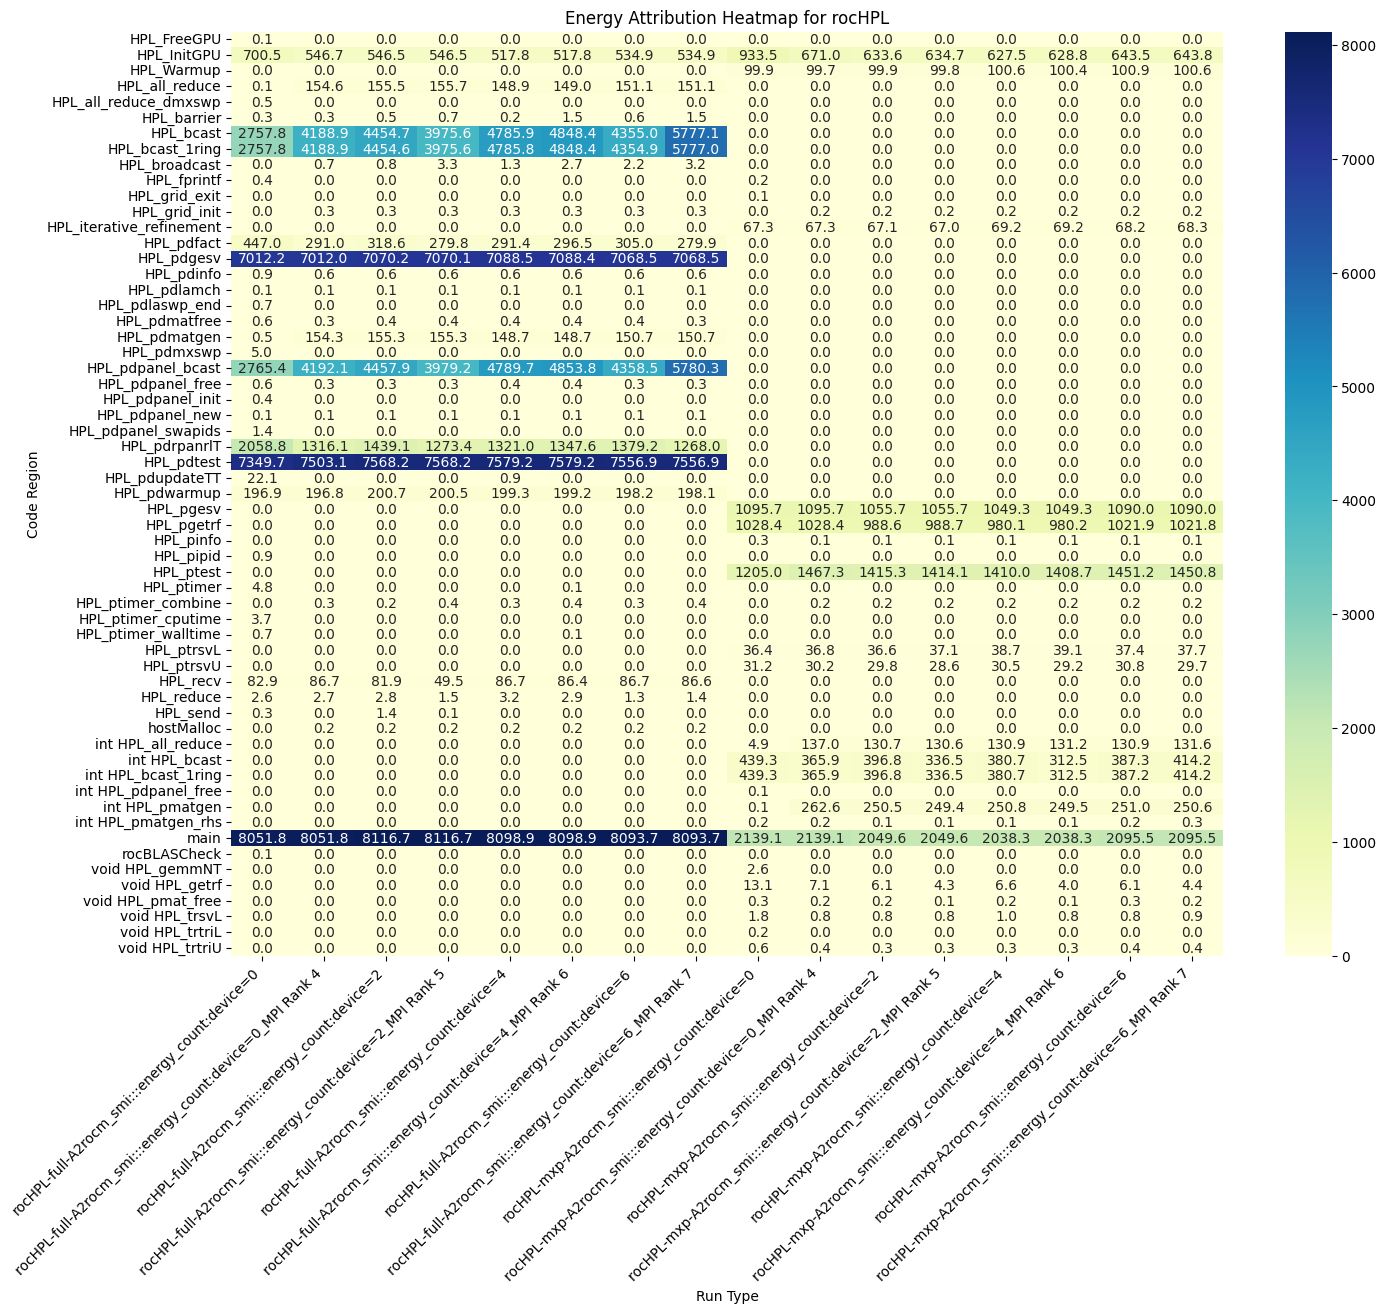

In [ ]:
# Average all the mxp runs and non-mxp runs each
rochpl_avg = rochpl_run_attributions.copy()
rochpl_avg = rochpl_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
rochpl_avg['Run'] = 'rocHPL-full'
# Sort the dataframe by value
# rochpl_avg = rochpl_avg.sort_values(by='Value', ascending=False)

rochpl_mxp_avg = rochpl_mxp_run_attributions.copy()
rochpl_mxp_avg = rochpl_mxp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
rochpl_mxp_avg['Run'] = 'rocHPL-mxp'


# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    """Replace the prefix and everything after the `<` or `(` in the function name."""
    name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()

rochpl_mxp_avg['Code Region'] = rochpl_mxp_avg['Code Region'].apply(replace_prefix_and_suffix)
rochpl_avg['Code Region'] = rochpl_avg['Code Region'].apply(replace_prefix_and_suffix)
visualize_dataframe(rochpl_avg)
visualize_dataframe(rochpl_mxp_avg)

# rochpl_mpi_funcs = rochpl_avg[rochpl_avg['Code Region'].str.contains('MPI')]
# rochpl_mxp_mpi_funcs = rochpl_mxp_avg[rochpl_mxp_avg['Code Region'].str.contains('MPI')]

heatmap_data = pd.concat([rochpl_avg, rochpl_mxp_avg])
heatmap_data = heatmap_data.pivot_table(index='Code Region', columns=['Run', 'Metric'], values='Value', fill_value=0.0, sort=True)
visualize_dataframe(heatmap_data)
# Sort by the sum of both columns

# Show the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Energy Attribution Heatmap for rocHPL")
plt.xlabel("Run Type")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Code Region")
plt.show()

# See Variations Across Individual Runs of rocHPL Full Precision

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,8131.156656
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,8063.641699
frontier02329-rochpl--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,7960.605040
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0,7391.108504
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0,7358.630506
frontier02329-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0,7299.416895
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdgesv,A2rocm_smi:::energy_count:device=0,7052.341094
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdgesv,A2rocm_smi:::energy_count:device=0,7017.716838
frontier02329-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdgesv,A2rocm_smi:::energy_count:device=0,6966.527685
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdpanel_bcast,A2rocm_smi:::energy_count:device=0,3118.558659


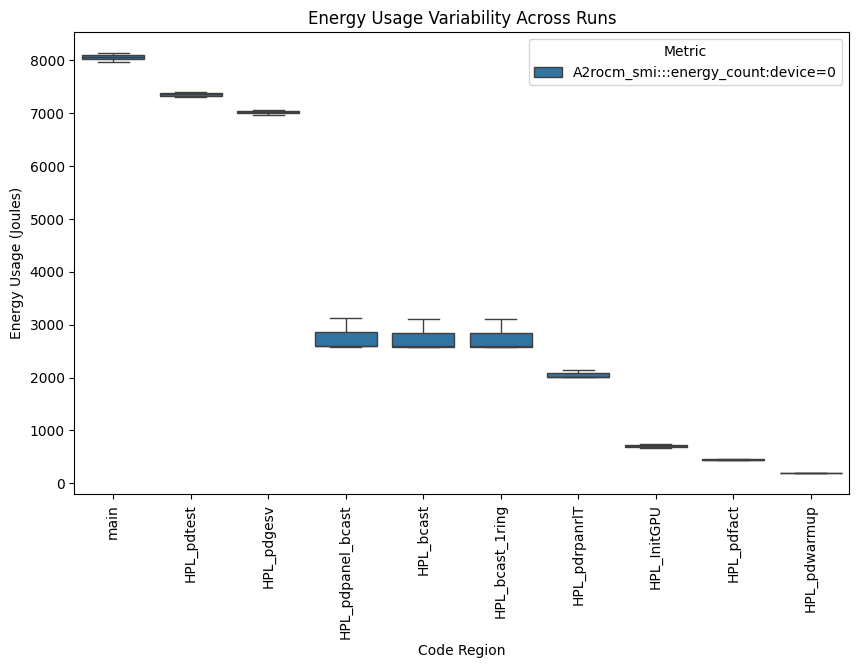

In [ ]:
run_attributions = rochpl_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~< >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'] == 'A2rocm_smi:::energy_count:device=0']
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across rocHPL Full Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier00137-rochplmxp--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,2141.262383
frontier00133-rochplmxp--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,2136.858745
frontier00133-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_ptest,A2rocm_smi:::energy_count:device=0,1213.381940
frontier00137-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_ptest,A2rocm_smi:::energy_count:device=0,1196.569667
frontier00133-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_pgesv,A2rocm_smi:::energy_count:device=0,1104.279943
frontier00137-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_pgesv,A2rocm_smi:::energy_count:device=0,1087.126555
frontier00133-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_pgetrf,A2rocm_smi:::energy_count:device=0,1037.108462
frontier00137-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_pgetrf,A2rocm_smi:::energy_count:device=0,1019.651769
frontier00137-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_InitGPU,A2rocm_smi:::energy_count:device=0,944.059696
frontier00133-rochplmxp--P_1_-Q_8_-N_180224,node0,HPLMXP_InitGPU,A2rocm_smi:::energy_count:device=0,922.955618


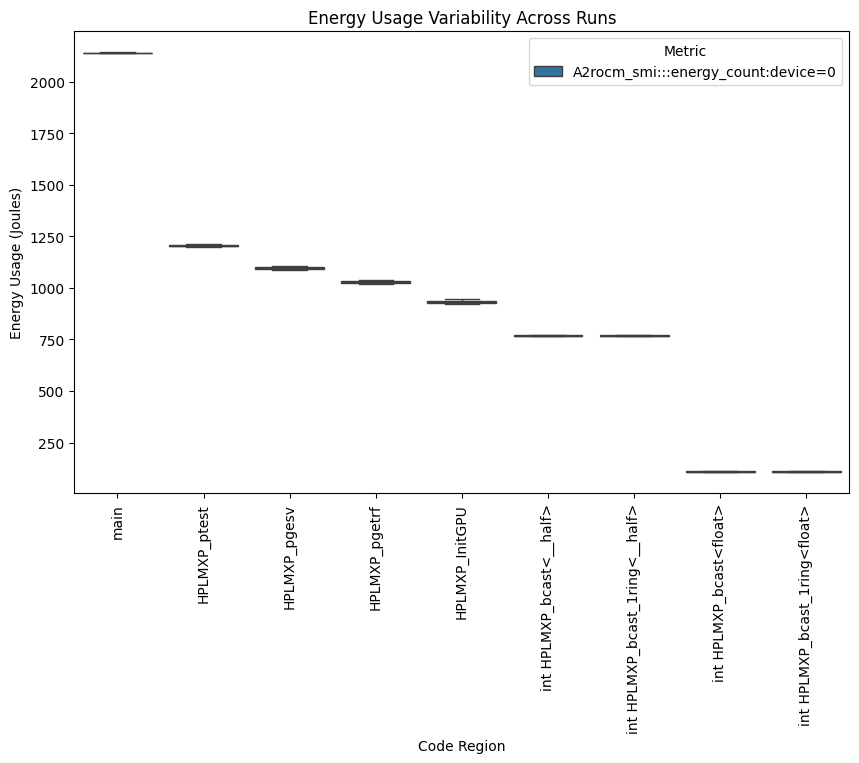

In [ ]:
run_attributions = rochpl_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~< >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'] == 'A2rocm_smi:::energy_count:device=0']
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across rocHPL Mixed Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

# Load HPG data

In [ ]:
hpg_runs = Ensemble.from_trace_paths(
    HPG_TRACES,
    {
		'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
	}
)

Loading run from trace path: ./scorep-traces/frontier00133-xhpgmp---runtype=standalone_ref/traces.otf2
Timer resolution: 1996127254 ticks per second (1.996127254 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x65acb1a90>
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread:  in group MPI Rank 0
Processed 74687701 events.
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_10971/4121998257.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.03770464e+08 1.03770464e+08 1.03770464e+08 ... 1.03775553e+08
 1.03775554e+08 1.03775554e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./scorep-traces/frontier00137-xhpgmp---runtype=standalone_ref/traces.otf2
Timer resolution: 1996127021 ticks per second (1.996127021 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x6d87aae90>
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 6
New thread:  in group MPI Rank 0
Processed 74639738 events.
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_10971/4121998257.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.03830205e+08 1.03830205e+08 1.03830206e+08 ... 1.03834877e+08
 1.03834878e+08 1.03834878e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [ ]:
hpg_mxp_runs = Ensemble.from_trace_paths(
    HPG_MXP_TRACES,
    {
		'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
	}
)

Loading run from trace path: ./scorep-traces/frontier00143-xhpgmp---runtype=standalone_mxp/traces.otf2
Timer resolution: 1996128544 ticks per second (1.996128544 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x6d87a9950>
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 74715332 events.
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 5_

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_10971/4121998257.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[65760870.769805 65760871.033838 65760871.301465 ... 65765758.826795
 65765759.019881 65765759.271382]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./scorep-traces/frontier00146-xhpgmp---runtype=standalone_mxp/traces.otf2
Timer resolution: 1996123747 ticks per second (1.996123747 per nanosecond)
Number of metric members: 27
Definitions: <otf2.registry.DefinitionRegistry object at 0x6d87a8550>
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 5
New thread:  in group MPI Rank 0
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv


# Compute the HPG energy breakdown

In [ ]:
hpg_run_attributions = hpg_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
	},
)

hpg_mxp_run_attributions = hpg_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
	}
)
                       

Computing attribution for run ./scorep-traces/frontier00133-xhpgmp---runtype=standalone_ref/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6', 'A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy']
Computing attribution for rank MPI Rank 0...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 1...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for rank MPI Rank 2...
['A2rocm_smi:::energy_count:device=4']
Computing attribution for rank MPI Rank 3...
['A2rocm_smi:::energy_count:device=6']
Computing attribution for rank MPI Rank 4...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 5...
['A2rocm_smi:::energy_count:device=2']
Computing attribution fo

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_93201/2482144794.py:253: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


Computing attribution for run ./scorep-traces/frontier00143-xhpgmp---runtype=standalone_mxp/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6', 'A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy']
Computing attribution for rank MPI Rank 0...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 1...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for rank MPI Rank 2...
['A2rocm_smi:::energy_count:device=4']
Computing attribution for rank MPI Rank 3...
['A2rocm_smi:::energy_count:device=6']
Computing attribution for rank MPI Rank 4...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 5...
['A2rocm_smi:::energy_count:device=2']
Computing attribution fo

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_93201/2482144794.py:253: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


# Illustrate the energy breakdown of HPG

Node,Code Region,Metric,Value,Run
node0,main,A2rocm_smi:::energy_count:device=0,9762.307836,HPG-full
node0,main,A2rocm_smi:::energy_count:device=4,9539.124175,HPG-full
node0,main,A2rocm_smi:::energy_count:device=2,9538.252010,HPG-full
node0,main,A2rocm_smi:::energy_count:device=6,9529.424663,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=0,8634.906671,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=4,8479.957223,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=2,8473.427386,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=6,8454.505709,HPG-full
node0,int ComputeMG,A2rocm_smi:::energy_count:device=0,7180.965269,HPG-full
node0,int ComputeMG,A2rocm_smi:::energy_count:device=0,7143.842538,HPG-full


Node,Code Region,Metric,Value,Run
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=0,74.331036,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=2,49.946655,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=4,49.359586,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=6,48.822285,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=0,0.134764,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=2,0.000000,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=4,0.000000,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=6,0.000000,HPG-mxp
node0,DeviceCtx::copy_device_to_host_async,A2rocm_smi:::energy_count:device=0,2.856378,HPG-mxp
node0,DeviceCtx::copy_device_to_host_async,A2rocm_smi:::energy_count:device=2,0.000000,HPG-mxp


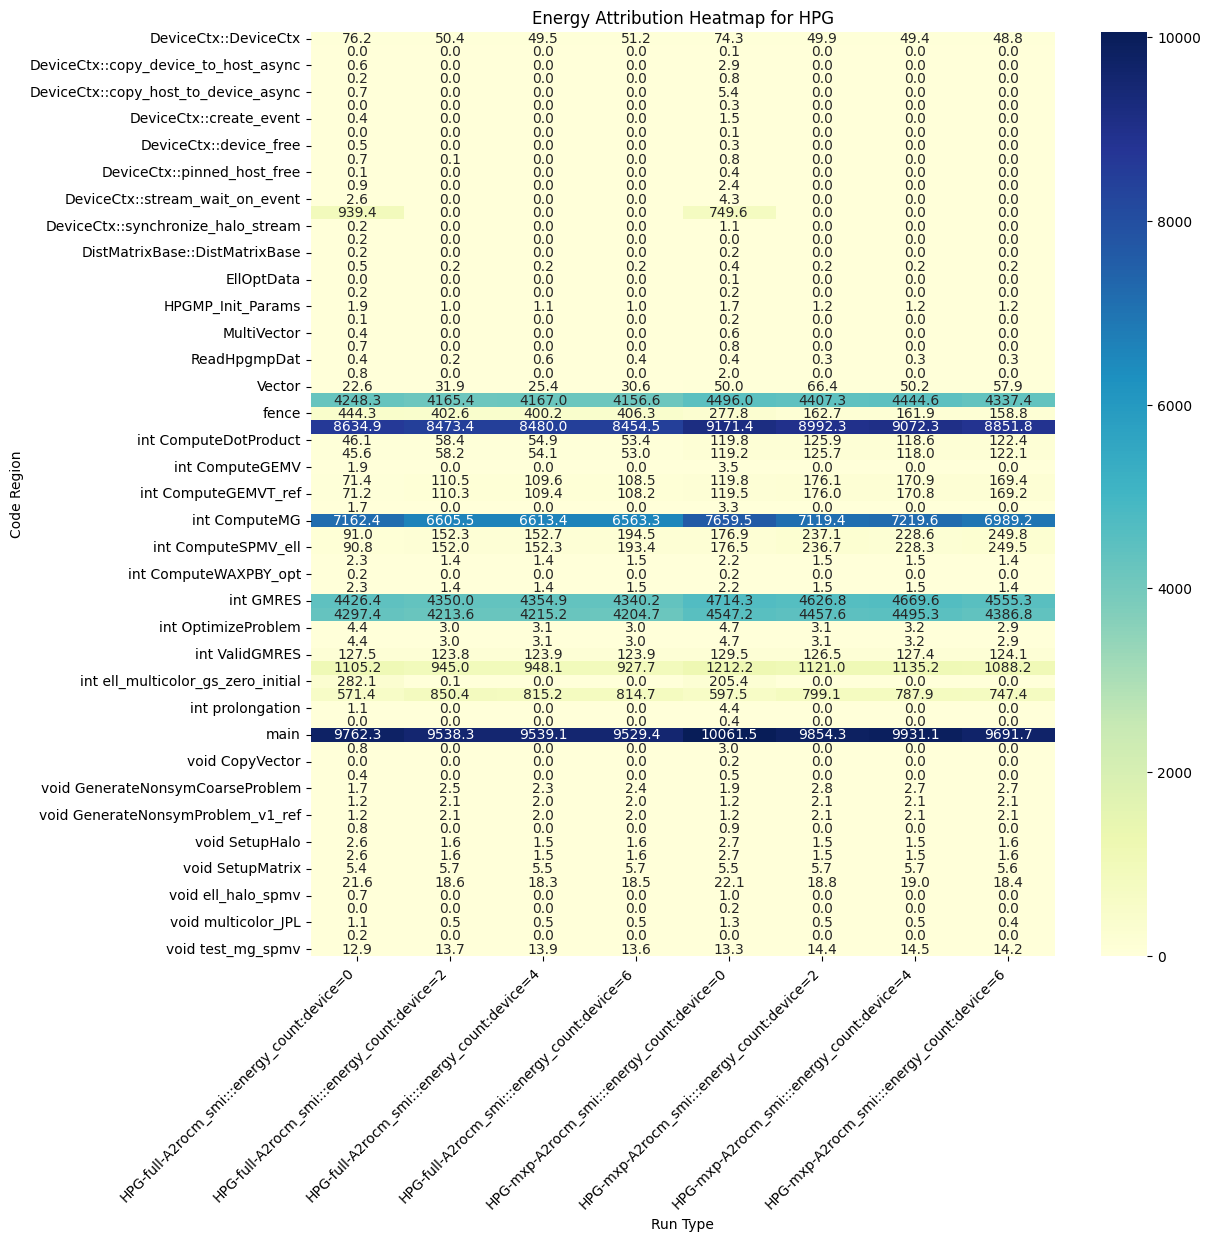

In [ ]:
# Average all the mxp runs and non-mxp runs each
hpg_avg = hpg_run_attributions.copy()
hpg_avg = hpg_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
hpg_avg['Run'] = 'HPG-full'
# Sort the dataframe by value
hpg_avg = hpg_avg.sort_values(by='Value', ascending=False)

hpg_mxp_avg = hpg_mxp_run_attributions.copy()
hpg_mxp_avg = hpg_mxp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
hpg_mxp_avg['Run'] = 'HPG-mxp'

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    """Replace the prefix and everything after the `<` or `(` in the function name."""
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()

hpg_mxp_avg['Code Region'] = hpg_mxp_avg['Code Region'].apply(replace_prefix_and_suffix)
hpg_avg['Code Region'] = hpg_avg['Code Region'].apply(replace_prefix_and_suffix)
visualize_dataframe(hpg_avg)
visualize_dataframe(hpg_mxp_avg)

# hpg_mpi_funcs = hpg_avg[hpg_avg['Code Region'].str.contains('MPI')]
# hpg_mxp_mpi_funcs = hpg_mxp_avg[hpg_mxp_avg['Code Region'].str.contains('MPI')]

heatmap_data = pd.concat([hpg_avg, hpg_mxp_avg])
heatmap_data = heatmap_data.pivot_table(index='Code Region', columns=['Run', 'Metric'], values='Value', fill_value=0.0, sort=True)
visualize_dataframe(heatmap_data)
# Sort by the sum of both columns

# Show the heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Energy Attribution Heatmap for HPG")
plt.xlabel("Run Type")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Code Region")
plt.show()

Computing attribution for run ./scorep-traces/frontier00137-rochpl--P_1_-Q_8_-N_180224/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6', 'A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy']
Computing attribution for rank MPI Rank 0...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 1...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for rank MPI Rank 2...
['A2rocm_smi:::energy_count:device=4']
Computing attribution for rank MPI Rank 3...
['A2rocm_smi:::energy_count:device=6']
Computing attribution for rank MPI Rank 4...
['A2rocm_smi:::energy_count:device=0']
Computing attribution for rank MPI Rank 5...
['A2rocm_smi:::energy_count:device=2']
Computing attribution for ran

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_11825/1870772748.py:248: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


Run,Node,Code Region,Metric,Value
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,16262.313313
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,main,A2rocm_smi:::energy_count:device=0,16127.283399
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0,14782.217009
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0,14717.261011
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdgesv,A2rocm_smi:::energy_count:device=0,14104.682188
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdgesv,A2rocm_smi:::energy_count:device=0,14035.433676
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdpanel_bcast,A2rocm_smi:::energy_count:device=0,6237.117318
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_bcast,A2rocm_smi:::energy_count:device=0,6221.382666
frontier00133-rochpl--P_1_-Q_8_-N_180224,node0,HPL_bcast_1ring,A2rocm_smi:::energy_count:device=0,6221.315167
frontier00137-rochpl--P_1_-Q_8_-N_180224,node0,HPL_pdpanel_bcast,A2rocm_smi:::energy_count:device=0,5198.669101


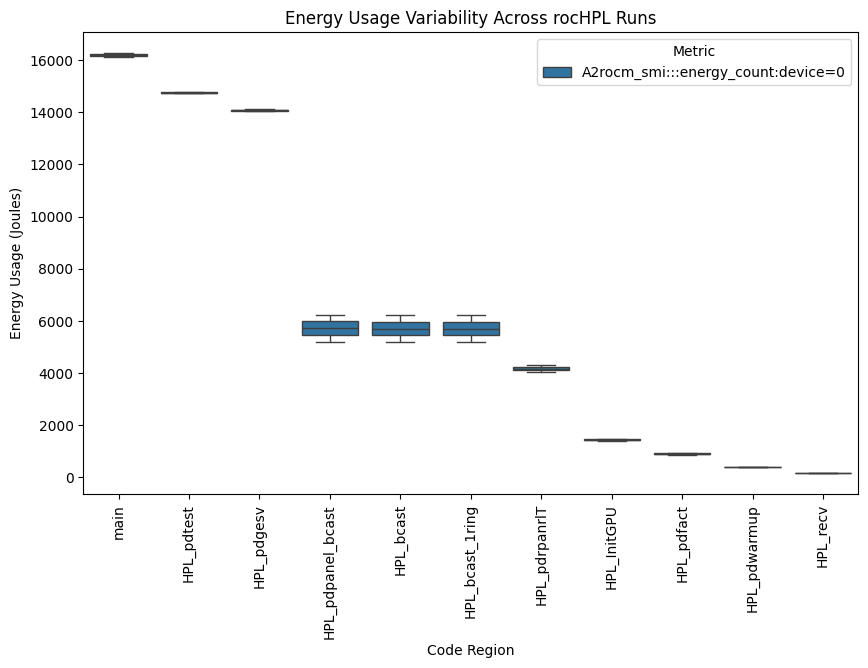

In [ ]:
run_attributions = hpg_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~< >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'] == 'A2rocm_smi:::energy_count:device=0']
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across HPG Full Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_11825/1870772748.py:248: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([result, pd.DataFrame({


Run,Node,Code Region,Metric,Value
frontier00133-xhpgmp---runtype=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0,5089.920876
frontier00137-xhpgmp---runtype=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0,4672.430421
frontier00133-xhpgmp---runtype=standalone_ref,node0,int BenchGMRES<double,A2rocm_smi:::energy_count:device=0,4525.928389
frontier00137-xhpgmp---runtype=standalone_ref,node0,int BenchGMRES<double,A2rocm_smi:::energy_count:device=0,4109.581504
frontier00133-xhpgmp---runtype=standalone_ref,node0,int ComputeMG<SparseMatrix<double>,A2rocm_smi:::energy_count:device=0,4061.593759
frontier00133-xhpgmp---runtype=standalone_ref,node0,int ComputeMG<SparseMatrix<float>,A2rocm_smi:::energy_count:device=0,3840.731281
frontier00137-xhpgmp---runtype=standalone_ref,node0,int ComputeMG<SparseMatrix<float>,A2rocm_smi:::energy_count:device=0,3658.148806
frontier00137-xhpgmp---runtype=standalone_ref,node0,int ComputeMG<SparseMatrix<double>,A2rocm_smi:::energy_count:device=0,3548.722450
frontier00133-xhpgmp---runtype=standalone_ref,node0,int GMRES<SparseMatrix<double>,A2rocm_smi:::energy_count:device=0,2334.357881
frontier00133-xhpgmp---runtype=standalone_ref,node0,int GMRES_IR<SparseMatrix<double>,A2rocm_smi:::energy_count:device=0,2235.984635


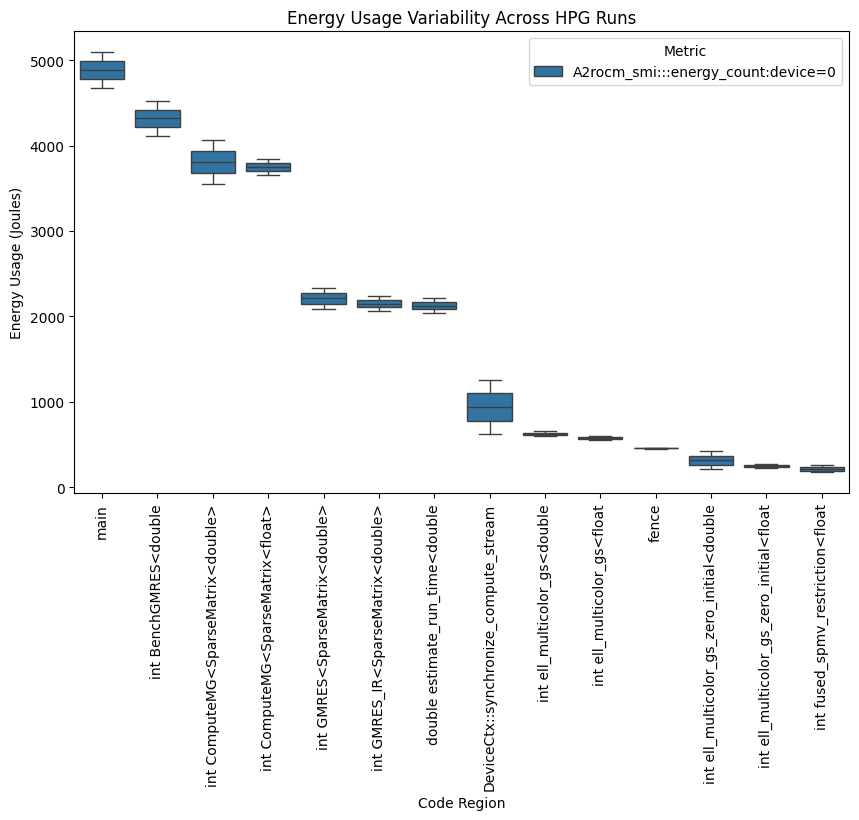

In [ ]:
run_attributions = hpg_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = {
        'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
        'MPI Rank 1': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 2': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 3': ['A2rocm_smi:::energy_count:device=6'],
		'MPI Rank 4': ['A2rocm_smi:::energy_count:device=0'],
		'MPI Rank 5': ['A2rocm_smi:::energy_count:device=2'],
		'MPI Rank 6': ['A2rocm_smi:::energy_count:device=4'],
		'MPI Rank 7': ['A2rocm_smi:::energy_count:device=6'],
    },
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~< >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'] == 'A2rocm_smi:::energy_count:device=0']
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across HPG Mixed Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()